Meeting: 12:30 Friday 2/10/26

Attendance:
Ben X
Tobias X

Recap:
We divided the project in two. Ben will look at stellar population and Tobias will look at dynamics.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# from matplotlib import rc
# %matplotlib inline
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
# rc('text', usetex=True)

In [12]:
harris_p1 = pd.read_csv('HarrisPartI.csv')
harris_p2 = pd.read_csv('HarrisPartII.csv')
harris_p3 = pd.read_csv('HarrisPartIII.csv')

Stellar population analysis - Ben

Stellar dynamics analysis - Tobias

In [13]:
R_gc = pd.to_numeric(harris_p1['R_gc'],errors='coerce')
X = pd.to_numeric(harris_p1['X'],errors='coerce')
Y = pd.to_numeric(harris_p1['Y'],errors='coerce')
Z = pd.to_numeric(harris_p1['Z'],errors='coerce')
R_Sun = pd.to_numeric(harris_p1['R_Sun'],errors='coerce')
sig_v = pd.to_numeric(harris_p3['sig_v'],errors='coerce')
v_r = pd.to_numeric(harris_p3['v_r'],errors='coerce')
mtlc = pd.to_numeric(harris_p2['[Fe/H]'],errors='coerce')
rho_0 = pd.to_numeric(harris_p3['rho_0'],errors='coerce')
mu_V = pd.to_numeric(harris_p3['mu_V'],errors='coerce')
c = pd.to_numeric(harris_p3['c'],errors='coerce')
BmV = pd.to_numeric(harris_p2['B-V'],errors='coerce')
ellip = pd.to_numeric(harris_p2['ellip'],errors='coerce')
r_c = pd.to_numeric(harris_p3['r_c'],errors='coerce')
r_h = pd.to_numeric(harris_p3['r_h'],errors='coerce')
M_V = pd.to_numeric(harris_p2['M_V,t'],errors='coerce')
V_t = pd.to_numeric(harris_p2['V_t'],errors='coerce')
wt = pd.to_numeric(harris_p2['wt'],errors='coerce')
L = pd.to_numeric(harris_p1['L'],errors='coerce')
B = pd.to_numeric(harris_p1['B'],errors='coerce')
mask = mtlc > -0.8

C:\Users\Elhol\AppData\Local\Temp\ipykernel_26884\3315956104.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


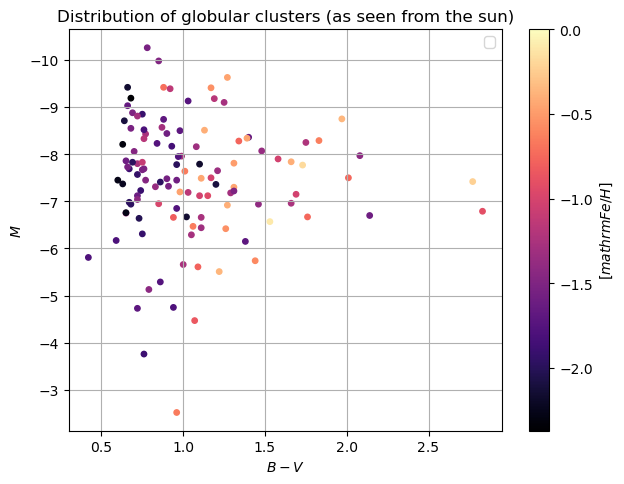

In [14]:
plt.figure()
plt.scatter(BmV,M_V,15,mtlc,cmap='magma',vmin=mtlc.min(),vmax=mtlc.max())
plt.colorbar(label ='$[mathrm{Fe/H}]$')
plt.xlabel('$B-V$')
plt.ylabel('$M$')
plt.legend()
plt.grid()
# plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.xlim()
plt.title('Distribution of globular clusters (as seen from the sun)')
plt.show()

In [15]:
X_gc = np.cos(L)*R_gc*np.sin(B)
Y_gc = np.sin(L)*R_gc*np.sin(B)
Z_gc = np.cos(B)*R_gc

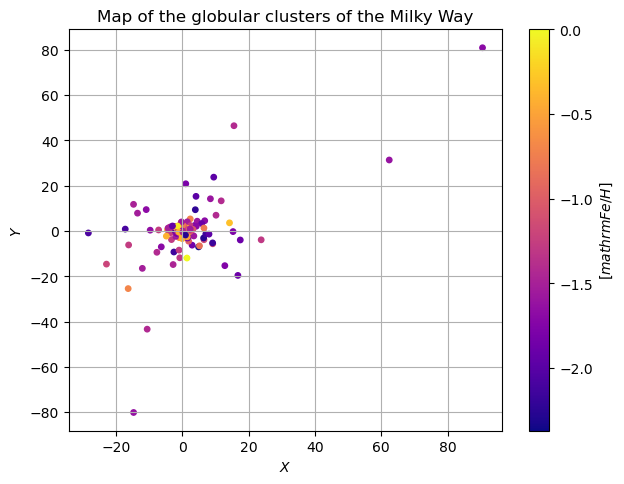

In [16]:
plt.figure()
plt.scatter(X_gc,Y_gc,15,mtlc,cmap='plasma',vmin=(mtlc).min(),vmax=(mtlc).max())
plt.colorbar(label ='$[mathrm{Fe/H}]$')
plt.xlabel('$X$')
plt.ylabel('$Y$')
# plt.legend()
plt.grid()
# plt.ylim(-25,25)
# plt.xlim(-25,25)
plt.tight_layout()
plt.title('Map of the globular clusters of the Milky Way')
plt.show()

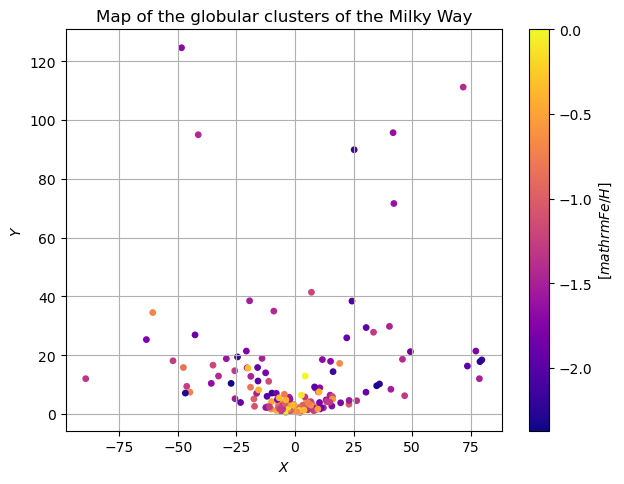

In [17]:
plt.figure()
plt.scatter(B,R_gc,15,mtlc,cmap='plasma',vmin=(mtlc).min(),vmax=(mtlc).max())
plt.colorbar(label ='$[mathrm{Fe/H}]$')
plt.xlabel('$X$')
plt.ylabel('$Y$')
# plt.legend()
plt.grid()
# plt.ylim(-25,25)
# plt.xlim(-25,25)
plt.tight_layout()
plt.title('Map of the globular clusters of the Milky Way')
plt.show()

In [18]:
from scipy.interpolate import RBFInterpolator
X_space = np.linspace(-25,25,3000)
Y_space = np.linspace(-25,25,3000)
X_space,Y_space = np.meshgrid(X_space,Y_space)
mask2 = np.isnan(X_gc) | np.isnan(Y_gc) | np.isnan(mtlc)
Xgc_arr = X_gc[~mask2]
Ygc_arr = Y_gc[~mask2]
mtlc_arr = mtlc[~mask2]
XgcYgc = np.transpose(np.array([Xgc_arr,Ygc_arr]))
rbf = RBFInterpolator(XgcYgc,mtlc_arr, kernel = 'thin_plate_spline')

# MM = griddata(RV,M_array,(RR,VV),method = 'cubic')
mtlc_space = rbf(np.column_stack((X_space.ravel(), Y_space.ravel()))).reshape(X_space.shape)

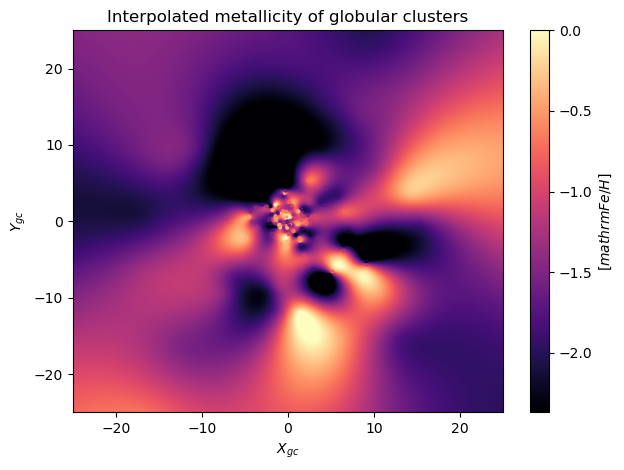

In [19]:
plt.figure()
plt.pcolormesh(X_space,Y_space,mtlc_space,cmap='magma',vmin=mtlc.min(),vmax=mtlc.max())
plt.scatter(X_gc,Y_gc,3,mtlc,cmap='magma',vmin=mtlc.min(),vmax=mtlc.max())
plt.colorbar(label ='$[mathrm{Fe/H}]$')
# plt.gca().invert_xaxis()
# plt.gca().invert_yaxis()
plt.xlabel('$X_{gc}$')
plt.ylabel('$Y_{gc}$')
plt.title('Interpolated metallicity of globular clusters')
plt.xlim(-25,25)
plt.ylim(-25,25)
plt.tight_layout()
plt.show()

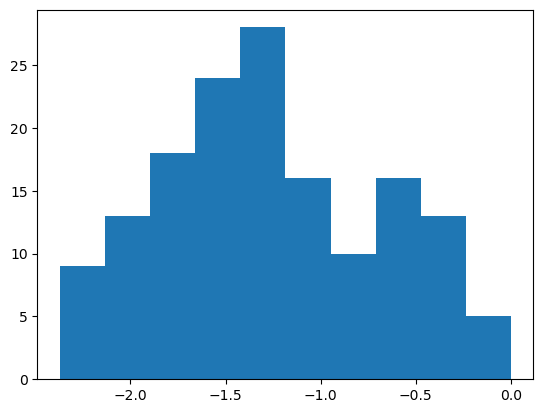

In [20]:
plt.figure()
plt.hist(mtlc)
plt.show()